<a href="https://colab.research.google.com/github/swirita/salmonellosis-forecasting-analysis/blob/main/notebooks/03_salmonellosis_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Weekly SARIMA Forecasting by Reporting Area

This notebook fits a separate SARIMA model to each reporting area's weekly **`Current week`** time series.

SARIMA remains a pure time-series model: it uses only the area's earlier weekly case counts. A weekly datetime index tells the model the order and frequency of those observations.

For a fair comparison with the recursive Random Forest, both models are tested on the same unseen window: **2025 Weeks 38–52**. After evaluation, both forecast **2026 Weeks 38–52**.

## Imports

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

## Helper Functions

In [2]:
def mmwr_week_end(year, week):
    """Return the Saturday at the end of an MMWR week."""
    january_4 = pd.Timestamp(year=int(year), month=1, day=4)
    days_since_sunday = (january_4.dayofweek + 1) % 7
    week_1_start = january_4 - pd.Timedelta(days=days_since_sunday)

    return (
        week_1_start
        + pd.Timedelta(weeks=int(week) - 1)
        + pd.Timedelta(days=6)
    )


def make_weekly_series(area_rows, end_date=None):
    """Create one regular W-SAT series for a single reporting area."""
    series = (
        area_rows
        .sort_values("Date")
        .drop_duplicates(subset="Date", keep="last")
        .set_index("Date")["Current week"]
        .astype(float)
    )

    if series.empty:
        return series

    final_date = pd.Timestamp(end_date) if end_date is not None else series.index.max()
    full_index = pd.date_range(series.index.min(), final_date, freq="W-SAT")
    return series.reindex(full_index).rename("Cases")


def fit_sarima(series, order, seasonal_order):
    """Fit one SARIMA model while allowing missing weeks in the history."""
    model = SARIMAX(
        series,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    return model.fit(disp=False, maxiter=100)


def regression_metrics(actual, predicted, label="SARIMA"):
    metrics = {
        "Model": label,
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": mean_squared_error(actual, predicted) ** 0.5,
        "R²": r2_score(actual, predicted),
    }
    return pd.DataFrame([metrics])

## Load and Prepare the Weekly Data

In [3]:
# Connect Google Colab to Google Drive
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
project_folder = "/content/drive/MyDrive/Salmonellosis Forecasting and Analysis"
data_folder = os.path.join(project_folder, "data")

cleaned_file_path = os.path.join(data_folder, "salmonellosis_weekly_cleaned.csv")
df = pd.read_csv(cleaned_file_path)

df["Current week"] = pd.to_numeric(df["Current week"], errors="coerce")
df["Date"] = [
    mmwr_week_end(year, week)
    for year, week in zip(df["Current MMWR Year"], df["MMWR WEEK"])
]

df = df.sort_values(
    ["Reporting Area", "Current MMWR Year", "MMWR WEEK"]
).reset_index(drop=True)

print(f"Data loaded: {df.shape[0]:,} rows")
print(f"Reporting areas: {df['Reporting Area'].nunique():,}")
print(f"Period: {df['Date'].min().date()} to {df['Date'].max().date()}")
display(df.head())

Data loaded: 17,079 rows
Reporting areas: 70
Period: 2022-01-08 to 2026-09-05


,Reporting Area,Current MMWR Year,MMWR WEEK,Label,Current week,Previous 52 week Max,Cumulative YTD Current MMWR Year,Cumulative YTD Previous MMWR Year,Season,Previous week cases,Date
0,ALABAMA,2022,1,Salmonellosis (excluding Salmonella Typhi infe...,10,38.0,10,6.0,Winter,2.0,2022-01-08
1,ALABAMA,2022,2,Salmonellosis (excluding Salmonella Typhi infe...,3,38.0,18,12.0,Winter,10.0,2022-01-15
2,ALABAMA,2022,3,Salmonellosis (excluding Salmonella Typhi infe...,0,38.0,24,17.0,Winter,3.0,2022-01-22
3,ALABAMA,2022,4,Salmonellosis (excluding Salmonella Typhi infe...,2,38.0,26,25.0,Winter,0.0,2022-01-29
4,ALABAMA,2022,5,Salmonellosis (excluding Salmonella Typhi infe...,0,38.0,29,30.0,Winter,2.0,2022-02-05


## Model Settings

`52` is used as the seasonal period because the data is weekly and a yearly pattern repeats approximately every 52 weeks.

The same SARIMA structure is used for every area so that the combined evaluation is consistent. Running `auto_arima` separately for every reporting area would be much slower and could give every area a different model specification.

In [5]:
SEASON_LENGTH = 52
SARIMA_ORDER = (1, 0, 1)
SARIMA_SEASONAL_ORDER = (1, 1, 0, SEASON_LENGTH)

VALIDATION_YEAR = 2025
VALIDATION_LAST_OBSERVED_WEEK = 37
VALIDATION_FIRST_FORECAST_WEEK = 38
VALIDATION_LAST_FORECAST_WEEK = 52

FORECAST_YEAR = 2026
LAST_OBSERVED_WEEK = 37
FIRST_FORECAST_WEEK = 38
LAST_FORECAST_WEEK = 52

# Two complete yearly cycles are required before fitting an area.
MIN_OBSERVED_WEEKS = 2 * SEASON_LENGTH

## 1. Fair 15-Week Validation

For every reporting area:

- Training history ends at 2025 Week 37.
- Weeks 38–52 remain unseen.
- SARIMA receives only the earlier weekly `Current week` series.
- It produces all 15 future weeks as a multi-step time-series forecast.

This matches the recursive Random Forest's cutoff and horizon without copying its features or modeling process.

In [6]:
validation_history_end = mmwr_week_end(
    VALIDATION_YEAR,
    VALIDATION_LAST_OBSERVED_WEEK,
)

validation_rows = []
skipped_validation_areas = []

for area in sorted(df["Reporting Area"].dropna().unique()):
    area_df = df[df["Reporting Area"] == area].copy()

    history_rows = area_df[
        (area_df["Current MMWR Year"] < VALIDATION_YEAR)
        | (
            (area_df["Current MMWR Year"] == VALIDATION_YEAR)
            & (area_df["MMWR WEEK"] <= VALIDATION_LAST_OBSERVED_WEEK)
        )
    ]

    test_rows = area_df[
        (area_df["Current MMWR Year"] == VALIDATION_YEAR)
        & area_df["MMWR WEEK"].between(
            VALIDATION_FIRST_FORECAST_WEEK,
            VALIDATION_LAST_FORECAST_WEEK,
        )
    ].dropna(subset=["Current week"])

    # This is the only input passed to SARIMA:
    # the area's ordered weekly case-count series.
    train_series = make_weekly_series(
        history_rows,
        end_date=validation_history_end,
    )

    if (
        train_series.notna().sum() < MIN_OBSERVED_WEEKS
        or test_rows.empty
    ):
        skipped_validation_areas.append(area)
        continue

    try:
        fitted_model = fit_sarima(
            train_series,
            SARIMA_ORDER,
            SARIMA_SEASONAL_ORDER,
        )

        prediction = fitted_model.get_forecast(
            steps=VALIDATION_LAST_FORECAST_WEEK - VALIDATION_FIRST_FORECAST_WEEK + 1
        ).summary_frame()

        prediction["mean"] = prediction["mean"].clip(lower=0)

        area_results = test_rows[
            ["Reporting Area", "Current MMWR Year", "MMWR WEEK", "Date", "Current week"]
        ].copy()

        area_results = area_results.merge(
            prediction[["mean"]],
            left_on="Date",
            right_index=True,
            how="left",
        ).rename(columns={"mean": "Forecast Current week"})

        validation_rows.append(area_results)

    except Exception as error:
        skipped_validation_areas.append(area)
        print(f"Skipped {area}: {error}")

sarima_validation_predictions = (
    pd.concat(validation_rows, ignore_index=True)
    .dropna(subset=["Forecast Current week"])
)

print(f"Evaluated areas: {sarima_validation_predictions['Reporting Area'].nunique()}")
print(f"Validation predictions: {len(sarima_validation_predictions):,}")
print(f"Skipped areas: {len(skipped_validation_areas)}")

sarima_validation_predictions.head()

Evaluated areas: 70
Validation predictions: 1,050
Skipped areas: 0


,Reporting Area,Current MMWR Year,MMWR WEEK,Date,Current week,Forecast Current week
0,ALABAMA,2025,38,2025-09-20,20,10.511513
1,ALABAMA,2025,39,2025-09-27,16,5.489223
2,ALABAMA,2025,40,2025-10-04,15,14.323790
3,ALABAMA,2025,41,2025-10-11,12,9.140907
4,ALABAMA,2025,42,2025-10-18,7,9.705637


In [7]:
sarima_metrics = regression_metrics(
    sarima_validation_predictions["Current week"],
    sarima_validation_predictions["Forecast Current week"],
    label="Weekly SARIMA — all reporting areas",
)

display(sarima_metrics.round({"MAE": 2, "RMSE": 2, "R²": 3}))

,Model,MAE,RMSE,R²
0,Weekly SARIMA — all reporting areas,7.01,17.43,0.971


### Check One Reporting Area

Change `area_to_plot` to inspect another reporting area. The graph shows only the shared 15-week validation window; the metrics use every evaluated area.

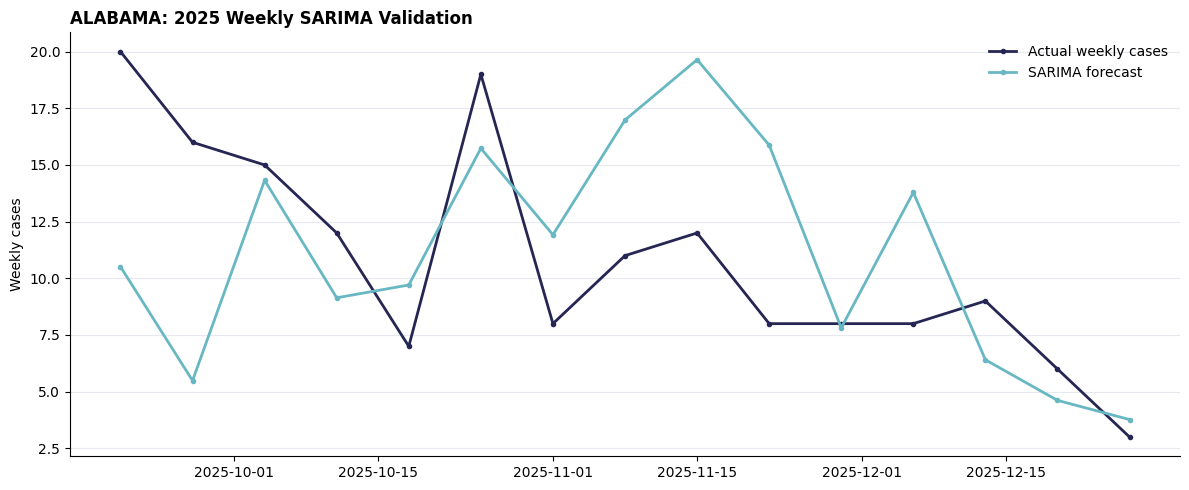

In [8]:
area_to_plot = "ALABAMA"

area_validation = sarima_validation_predictions[
    sarima_validation_predictions["Reporting Area"] == area_to_plot
].sort_values("Date")

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    area_validation["Date"],
    area_validation["Current week"],
    color="#252653",
    marker="o",
    markersize=3,
    linewidth=2,
    label="Actual weekly cases",
)
ax.plot(
    area_validation["Date"],
    area_validation["Forecast Current week"],
    color="#68B8C4",
    marker="o",
    markersize=3,
    linewidth=2,
    label="SARIMA forecast",
)

ax.set_title(f"{area_to_plot}: 2025 Weekly SARIMA Validation", loc="left", fontweight="bold")
ax.set_ylabel("Weekly cases")
ax.set_xlabel("")
ax.grid(axis="y", color="#E7E9F0")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 2. Forecast 2026 Weeks 38–52 for Every Reporting Area

Each final SARIMA model is refitted using that reporting area's history through Week 37 of 2026. SARIMA produces a multi-step forecast recursively, so later weeks depend on the model's earlier forecasted values.

In [9]:
history_end_date = mmwr_week_end(FORECAST_YEAR, LAST_OBSERVED_WEEK)
future_weeks = list(range(FIRST_FORECAST_WEEK, LAST_FORECAST_WEEK + 1))
future_dates = [mmwr_week_end(FORECAST_YEAR, week) for week in future_weeks]

forecast_rows = []
skipped_forecast_areas = []

for area in sorted(df["Reporting Area"].dropna().unique()):
    area_df = df[df["Reporting Area"] == area].copy()

    history_rows = area_df[
        (area_df["Current MMWR Year"] < FORECAST_YEAR)
        | (
            (area_df["Current MMWR Year"] == FORECAST_YEAR)
            & (area_df["MMWR WEEK"] <= LAST_OBSERVED_WEEK)
        )
    ]

    history_series = make_weekly_series(
        history_rows,
        end_date=history_end_date,
    )

    if history_series.notna().sum() < MIN_OBSERVED_WEEKS:
        skipped_forecast_areas.append(area)
        continue

    try:
        final_model = fit_sarima(
            history_series,
            SARIMA_ORDER,
            SARIMA_SEASONAL_ORDER,
        )

        area_forecast = final_model.get_forecast(
            steps=len(future_weeks)
        ).summary_frame()

        means = area_forecast["mean"].to_numpy().clip(min=0)
        lower = area_forecast["mean_ci_lower"].to_numpy().clip(min=0)
        upper = area_forecast["mean_ci_upper"].to_numpy().clip(min=0)

        for week, forecast_date, mean, low, high in zip(
            future_weeks,
            future_dates,
            means,
            lower,
            upper,
        ):
            forecast_rows.append({
                "Reporting Area": area,
                "Current MMWR Year": FORECAST_YEAR,
                "MMWR WEEK": week,
                "Date": forecast_date,
                "Forecast Current week": mean,
                "Lower 95% CI": low,
                "Upper 95% CI": high,
            })

    except Exception as error:
        skipped_forecast_areas.append(area)
        print(f"Skipped {area}: {error}")

forecast = pd.DataFrame(forecast_rows)

print(f"Forecasted areas: {forecast['Reporting Area'].nunique()}")
print(f"Forecast rows: {len(forecast):,}")
print(f"Skipped areas: {len(skipped_forecast_areas)}")

forecast.head(10)

Forecasted areas: 70
Forecast rows: 1,050
Skipped areas: 0


,Reporting Area,Current MMWR Year,MMWR WEEK,Date,Forecast Current week,Lower 95% CI,Upper 95% CI
0,ALABAMA,2026,38,2026-09-26,8.931316,0.000000,20.189090
1,ALABAMA,2026,39,2026-10-03,11.426080,0.000000,22.907054
2,ALABAMA,2026,40,2026-10-10,8.442331,0.000000,20.076467
3,ALABAMA,2026,41,2026-10-17,5.193557,0.000000,16.933350
4,ALABAMA,2026,42,2026-10-24,14.598414,2.785478,26.411350
5,ALABAMA,2026,43,2026-10-31,7.517601,0.000000,19.381293
6,ALABAMA,2026,44,2026-11-07,11.394336,0.000000,23.293304
7,ALABAMA,2026,45,2026-11-14,14.573007,2.649492,26.496521
8,ALABAMA,2026,46,2026-11-21,11.447349,0.000000,23.387957
9,ALABAMA,2026,47,2026-11-28,4.935758,0.000000,16.888274


### Plot the Weekly Forecast for One Reporting Area

This plot uses the same 2026 Week 38–52 horizon as the recursive Random Forest. It does not combine the areas into a national total.

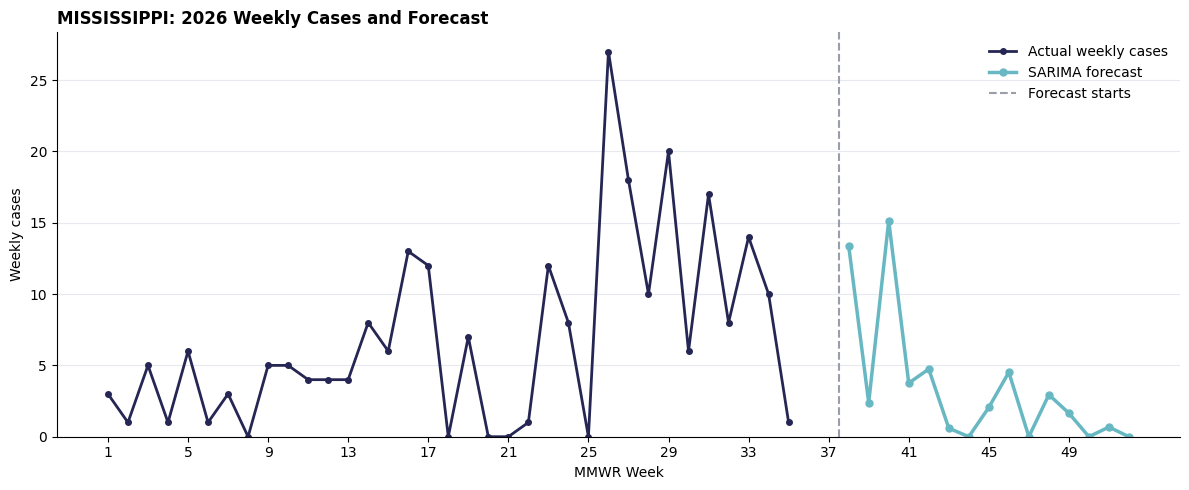

In [14]:
area_to_plot = "MISSISSIPPI"

actual = df[
    (df["Reporting Area"] == area_to_plot)
    & (df["Current MMWR Year"] == FORECAST_YEAR)
    & (df["MMWR WEEK"] <= LAST_OBSERVED_WEEK)
].sort_values("MMWR WEEK")

future = forecast[
    forecast["Reporting Area"] == area_to_plot
].sort_values("MMWR WEEK")

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    actual["MMWR WEEK"],
    actual["Current week"],
    color="#252653",
    marker="o",
    markersize=4,
    linewidth=2,
    label="Actual weekly cases",
)
ax.plot(
    future["MMWR WEEK"],
    future["Forecast Current week"],
    color="#68B8C4",
    marker="o",
    markersize=5,
    linewidth=2.5,
    label="SARIMA forecast",
)

ax.axvline(
    LAST_OBSERVED_WEEK + 0.5,
    color="#9A9DAA",
    linestyle="--",
    linewidth=1.5,
    label="Forecast starts",
)

ax.set_title(
    f"{area_to_plot}: 2026 Weekly Cases and Forecast",
    loc="left",
    fontweight="bold",
)
ax.set_xlabel("MMWR Week")
ax.set_ylabel("Weekly cases")
ax.set_xticks(range(1, 53, 4))
ax.set_ylim(bottom=0)
ax.grid(axis="y", color="#E7E9F0")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## Comparison With the Recursive Random Forest

The comparison is now aligned on:

- **Target:** `Current week`
- **Unit:** reporting area × MMWR week
- **Training cutoff:** Week 37
- **Unseen validation window:** 2025 Weeks 38–52
- **Future forecast window:** 2026 Weeks 38–52
- **Metrics:** MAE, RMSE, and R² on the same area-week observations

Only the evaluation setup is shared. SARIMA uses each area's weekly case history alone. The Random Forest uses its engineered features and recursively feeds predictions into later weeks.

In [15]:
## Final Evaluation

# Choose the reporting area
area_to_plot = "MISSISSIPPI"

# Keep this area's SARIMA forecast
area_final = (
    forecast[
        forecast["Reporting Area"] == area_to_plot
    ]
    .sort_values("MMWR WEEK")
    .copy()
)

if area_final.empty:
    raise ValueError(f"No forecast found for {area_to_plot}")

# Beginning and final forecast values
starting_value = area_final["Forecast Current week"].iloc[0]
final_value = area_final["Forecast Current week"].iloc[-1]

# Calculate the change
delta = final_value - starting_value

if starting_value != 0:
    percent_change = (delta / starting_value) * 100
else:
    percent_change = np.nan

print(f"Reporting area: {area_to_plot}")
print(f"Beginning forecast: {starting_value:,.0f} cases")
print(f"Final forecast: {final_value:,.0f} cases")
print(f"Net change in cases: {delta:+,.0f} cases")

if pd.notna(percent_change):
    print(f"Percentage change: {percent_change:+.2f}%")
else:
    print("Percentage change: unavailable because the starting value is zero")

Reporting area: MISSISSIPPI
Beginning forecast: 13 cases
Final forecast: 0 cases
Net change in cases: -13 cases
Percentage change: -100.00%


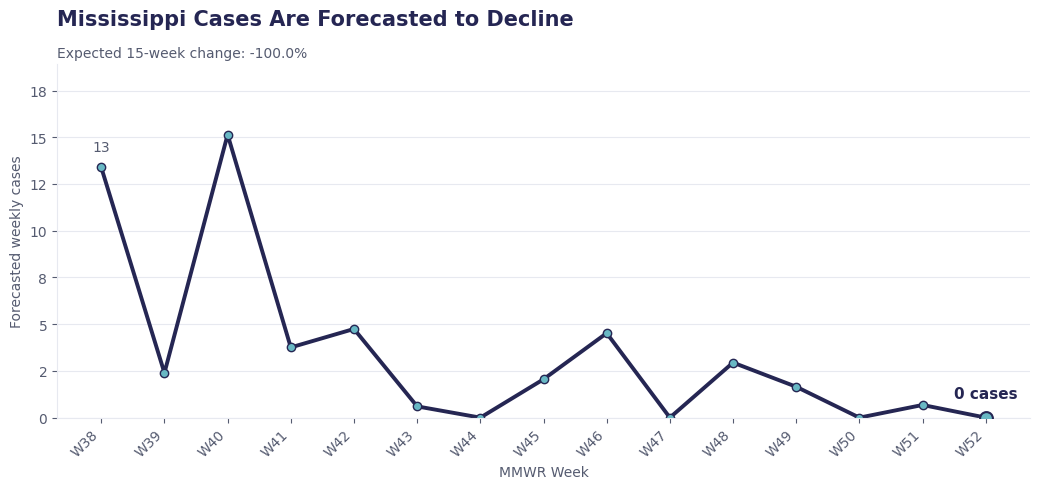

In [16]:
# Colors matching the analysis notebook
NAVY = "#252653"
CYAN = "#68B8C4"
LIGHT_GRAY = "#E7E9F0"
TEXT_GRAY = "#555B70"

# Create a dynamic title
if delta > 0:
    direction = "Increase"
elif delta < 0:
    direction = "Decline"
else:
    direction = "Remain Stable"

fig, ax = plt.subplots(figsize=(10.5, 5))

# Plot the weekly SARIMA forecast
ax.plot(
    area_final["MMWR WEEK"],
    area_final["Forecast Current week"],
    color=NAVY,
    linewidth=2.8,
    marker="o",
    markersize=6,
    markerfacecolor=CYAN,
    markeredgecolor=NAVY,
)

# Emphasize the final point
ax.scatter(
    area_final["MMWR WEEK"].iloc[-1],
    final_value,
    s=85,
    color=CYAN,
    edgecolor=NAVY,
    linewidth=1.5,
    zorder=3,
)

# Label the starting value
ax.annotate(
    f"{starting_value:,.0f}",
    xy=(
        area_final["MMWR WEEK"].iloc[0],
        starting_value,
    ),
    xytext=(0, 12),
    textcoords="offset points",
    ha="center",
    color=TEXT_GRAY,
    fontsize=10,
)

# Label the final value
ax.annotate(
    f"{final_value:,.0f} cases",
    xy=(
        area_final["MMWR WEEK"].iloc[-1],
        final_value,
    ),
    xytext=(0, 14),
    textcoords="offset points",
    ha="center",
    color=NAVY,
    fontsize=11,
    fontweight="bold",
)

# Title
ax.set_title(
    f"{area_to_plot.title()} Cases Are Forecasted to {direction}",
    fontsize=15,
    fontweight="bold",
    color=NAVY,
    loc="left",
    pad=28,
)

# Subtitle
change_text = (
    f"Expected 15-week change: {percent_change:+.1f}%"
    if pd.notna(percent_change)
    else "Expected 15-week change: unavailable"
)

ax.text(
    0,
    1.02,
    change_text,
    transform=ax.transAxes,
    fontsize=10,
    color=TEXT_GRAY,
)

# Format the axes
ax.set_ylabel("Forecasted weekly cases", color=TEXT_GRAY)
ax.set_xlabel("MMWR Week", color=TEXT_GRAY)

ax.set_xticks(area_final["MMWR WEEK"])
ax.set_xticklabels(
    [f"W{week}" for week in area_final["MMWR WEEK"]],
    rotation=45,
    ha="right",
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:,.0f}")
)

# Start at zero to avoid exaggerating the change
highest_value = area_final["Forecast Current week"].max()

ax.set_ylim(
    0,
    max(highest_value * 1.25, 1),
)

# Clean styling
ax.grid(
    axis="y",
    color=LIGHT_GRAY,
    linewidth=0.8,
)

ax.grid(axis="x", visible=False)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(LIGHT_GRAY)
ax.tick_params(colors=TEXT_GRAY)

plt.tight_layout()
plt.show()

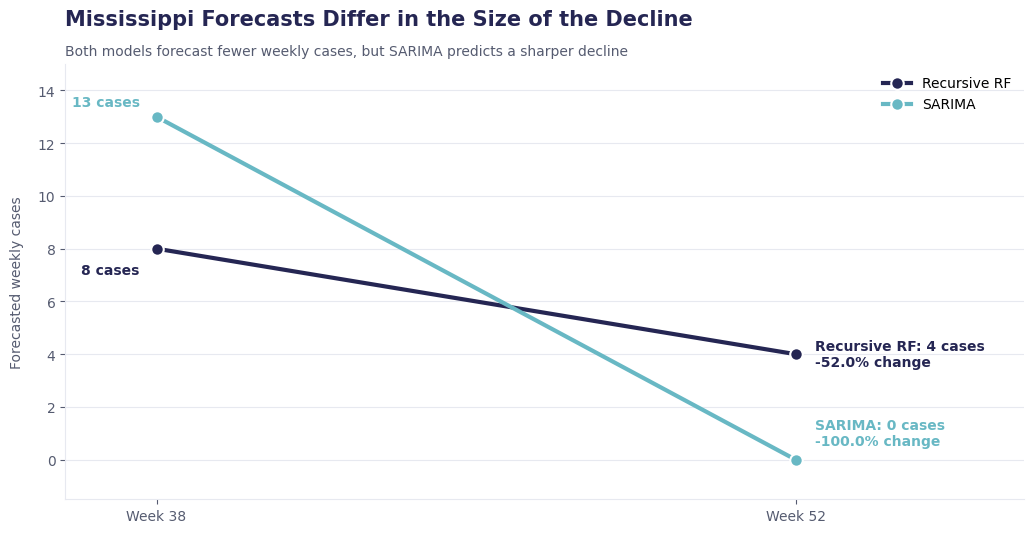

In [17]:
import matplotlib.pyplot as plt

# Mississippi forecast results
weeks = [38, 52]

recursive_values = [8, 4]
sarima_values = [13, 0]

recursive_change = -52.03
sarima_change = -100.00

# Report theme
NAVY = "#252653"
CYAN = "#68B8C4"
LIGHT_GRAY = "#E7E9F0"
TEXT_GRAY = "#555B70"

fig, ax = plt.subplots(figsize=(10.5, 5.5))

fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Recursive Random Forest
ax.plot(
    weeks,
    recursive_values,
    color=NAVY,
    linewidth=3,
    marker="o",
    markersize=9,
    markerfacecolor=NAVY,
    markeredgecolor="white",
    markeredgewidth=1.5,
    label="Recursive RF",
)

# SARIMA
ax.plot(
    weeks,
    sarima_values,
    color=CYAN,
    linewidth=3,
    marker="o",
    markersize=9,
    markerfacecolor=CYAN,
    markeredgecolor="white",
    markeredgewidth=1.5,
    label="SARIMA",
)

# Starting-value annotations
ax.annotate(
    "8 cases",
    xy=(38, 8),
    xytext=(-12, -18),
    textcoords="offset points",
    ha="right",
    color=NAVY,
    fontsize=10,
    fontweight="bold",
)

ax.annotate(
    "13 cases",
    xy=(38, 13),
    xytext=(-12, 8),
    textcoords="offset points",
    ha="right",
    color=CYAN,
    fontsize=10,
    fontweight="bold",
)

# Final-value annotations
ax.annotate(
    f"Recursive RF: 4 cases\n{recursive_change:+.1f}% change",
    xy=(52, 4),
    xytext=(14, 0),
    textcoords="offset points",
    ha="left",
    va="center",
    color=NAVY,
    fontsize=10,
    fontweight="bold",
)

ax.annotate(
    f"SARIMA: 0 cases\n{sarima_change:+.1f}% change",
    xy=(52, 0),
    xytext=(14, 8),
    textcoords="offset points",
    ha="left",
    va="bottom",
    color=CYAN,
    fontsize=10,
    fontweight="bold",
)

# Title and subtitle
ax.set_title(
    "Mississippi Forecasts Differ in the Size of the Decline",
    fontsize=15,
    fontweight="bold",
    color=NAVY,
    loc="left",
    pad=28,
)

ax.text(
    0,
    1.02,
    "Both models forecast fewer weekly cases, but SARIMA predicts a sharper decline",
    transform=ax.transAxes,
    fontsize=10,
    color=TEXT_GRAY,
)

# Axis formatting
ax.set_ylabel(
    "Forecasted weekly cases",
    color=TEXT_GRAY,
    labelpad=10,
)

ax.set_xlabel("")

ax.set_xticks(weeks)
ax.set_xticklabels(
    ["Week 38", "Week 52"],
    fontsize=10,
)

# Extra room for annotations
ax.set_xlim(36, 57)
ax.set_ylim(-1.5, 15)

ax.grid(
    axis="y",
    color=LIGHT_GRAY,
    linewidth=0.8,
)

ax.grid(axis="x", visible=False)

ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(LIGHT_GRAY)

ax.tick_params(colors=TEXT_GRAY)

ax.legend(
    frameon=False,
    loc="upper right",
)

plt.tight_layout(pad=1.3)
plt.show()

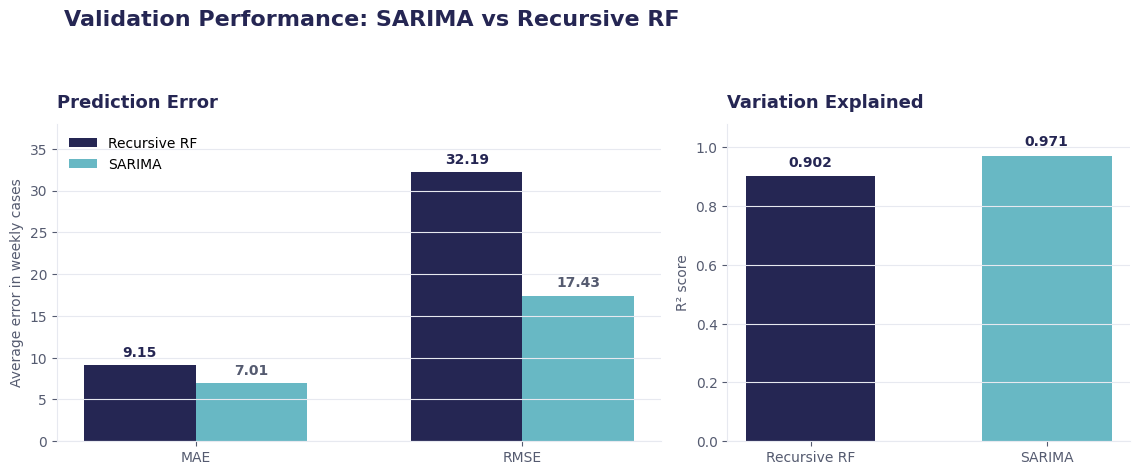

In [20]:
# Validation metrics
models = ["Recursive RF", "SARIMA"]

mae_values = [9.15, 7.01]
rmse_values = [32.19, 17.43]
r2_values = [0.902, 0.971]

# Report theme
NAVY = "#252653"
CYAN = "#68B8C4"
LIGHT_GRAY = "#E7E9F0"
TEXT_GRAY = "#555B70"

fig, (ax_error, ax_r2) = plt.subplots(
    1,
    2,
    figsize=(11.5, 4.8),
    gridspec_kw={
        "width_ratios": [1.5, 1]
    },
)

fig.patch.set_facecolor("white")

# Main title
fig.suptitle(
    "Validation Performance: SARIMA vs Recursive RF",
    x=0.06,
    y=0.98,
    ha="left",
    fontsize=16,
    fontweight="bold",
    color=NAVY,
)

# --------------------------------
# Panel 1: MAE and RMSE
# --------------------------------

metric_names = ["MAE", "RMSE"]
x_positions = np.arange(len(metric_names))
bar_width = 0.34

recursive_errors = [
    mae_values[0],
    rmse_values[0],
]

sarima_errors = [
    mae_values[1],
    rmse_values[1],
]

recursive_bars = ax_error.bar(
    x_positions - bar_width / 2,
    recursive_errors,
    width=bar_width,
    color=NAVY,
    label="Recursive RF",
)

sarima_bars = ax_error.bar(
    x_positions + bar_width / 2,
    sarima_errors,
    width=bar_width,
    color=CYAN,
    label="SARIMA",
)

# Bar values
ax_error.bar_label(
    recursive_bars,
    labels=[
        f"{value:.2f}"
        for value in recursive_errors
    ],
    padding=4,
    fontsize=10,
    color=NAVY,
    fontweight="bold",
)

ax_error.bar_label(
    sarima_bars,
    labels=[
        f"{value:.2f}"
        for value in sarima_errors
    ],
    padding=4,
    fontsize=10,
    color=TEXT_GRAY,
    fontweight="bold",
)

ax_error.set_title(
    "Prediction Error",
    loc="left",
    fontsize=13,
    fontweight="bold",
    color=NAVY,
    pad=12,
)

ax_error.set_xticks(x_positions)
ax_error.set_xticklabels(metric_names)

ax_error.set_ylabel(
    "Average error in weekly cases",
    color=TEXT_GRAY,
)

ax_error.set_ylim(
    0,
    max(recursive_errors + sarima_errors) * 1.18,
)

ax_error.grid(
    axis="y",
    color=LIGHT_GRAY,
    linewidth=0.8,
)

ax_error.grid(axis="x", visible=False)

ax_error.spines[
    ["top", "right"]
].set_visible(False)

ax_error.spines[
    ["left", "bottom"]
].set_color(LIGHT_GRAY)

ax_error.tick_params(colors=TEXT_GRAY)

ax_error.legend(
    frameon=False,
    loc="upper left",
)

# --------------------------------
# Panel 2: R²
# --------------------------------

r2_bars = ax_r2.bar(
    models,
    r2_values,
    color=[NAVY, CYAN],
    width=0.55,
)

ax_r2.bar_label(
    r2_bars,
    labels=[
        f"{value:.3f}"
        for value in r2_values
    ],
    padding=5,
    fontsize=10,
    color=NAVY,
    fontweight="bold",
)

ax_r2.set_title(
    "Variation Explained",
    loc="left",
    fontsize=13,
    fontweight="bold",
    color=NAVY,
    pad=12,
)

ax_r2.set_ylabel(
    "R² score",
    color=TEXT_GRAY,
)

ax_r2.set_ylim(0, 1.08)

ax_r2.grid(
    axis="y",
    color=LIGHT_GRAY,
    linewidth=0.8,
)

ax_r2.grid(axis="x", visible=False)

ax_r2.spines[
    ["top", "right"]
].set_visible(False)

ax_r2.spines[
    ["left", "bottom"]
].set_color(LIGHT_GRAY)

ax_r2.tick_params(colors=TEXT_GRAY)

plt.tight_layout(
    rect=[0, 0, 1, 0.91]
)

plt.show()